# Notebook 04 — Cohort + RFM Dashboard Final
**Tujuan:** Layout satu halaman siap presentasi — KPI cards + cohort heatmap + RFM + CLV.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

OUT = Path('../output')

BLUE    = '#2563EB'
LIGHT   = '#93C5FD'
LIGHTER = '#DBEAFE'
RED     = '#DC2626'
GRAY    = '#6B7280'
BG      = '#F8FAFC'

SEG_COLORS = {
    'Champions':          '#1D4ED8',
    'Loyal Customers':    '#2563EB',
    'Big Spenders':       '#7C3AED',
    'Potential Loyalist': '#0891B2',
    'New Customers':      '#059669',
    'At Risk':            '#F59E0B',
    'Hibernating':        '#EF4444',
    'Lost':               '#DC2626',
}

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': BG,
    'axes.facecolor': '#FFFFFF',
})

df_rfm      = pd.read_parquet(OUT / 'df_rfm.parquet')
retention   = pd.read_parquet(OUT / 'cohort_retention.parquet')
print('Data loaded.')

Data loaded.


In [3]:
# ── Pre-compute KPI ──────────────────────────────────────────────────────
total_customers   = len(df_rfm)
m1_retention      = retention.iloc[:, 1].mean() if retention.shape[1] > 1 else 0.0
champ_loyal_pct   = len(df_rfm[df_rfm['segment'].isin(['Champions', 'Loyal Customers'])]) / total_customers
avg_clv           = df_rfm['clv_estimate'].mean()

print(f"Total Customers  : {total_customers:,}")
print(f"M+1 Retention    : {m1_retention:.1%}  {'(tidak ada repeat buyer)' if m1_retention == 0 else ''}")
print(f"Champions+Loyal  : {champ_loyal_pct:.1%}")
print(f"Avg CLV          : {avg_clv:,.2f}")

# RFM segment distribution
seg_dist = df_rfm['segment'].value_counts().sort_values()

# CLV per segment
clv_seg = df_rfm.groupby('segment')['clv_estimate'].mean().sort_values()

# Cohort heatmap data
ret_plot = retention.copy()
ret_plot.index = ret_plot.index.astype(str)
ret_plot.columns = [f'M+{c}' for c in ret_plot.columns]
ret_plot = ret_plot.iloc[:, :13]  # batasi 12 bulan

print(f'Customers    : {total_customers:,}')
print(f'M1 Retention : {m1_retention:.1%}')
print(f'Champions+Loyal: {champ_loyal_pct:.1%}')
print(f'Avg CLV      : R$ {avg_clv:,.2f}')

Total Customers  : 96,478
M+1 Retention    : 0.0%  (tidak ada repeat buyer)
Champions+Loyal  : 0.0%
Avg CLV          : 248.34
Customers    : 96,478
M1 Retention : 0.0%
Champions+Loyal: 0.0%
Avg CLV      : R$ 248.34


Saved: output/dashboard.png


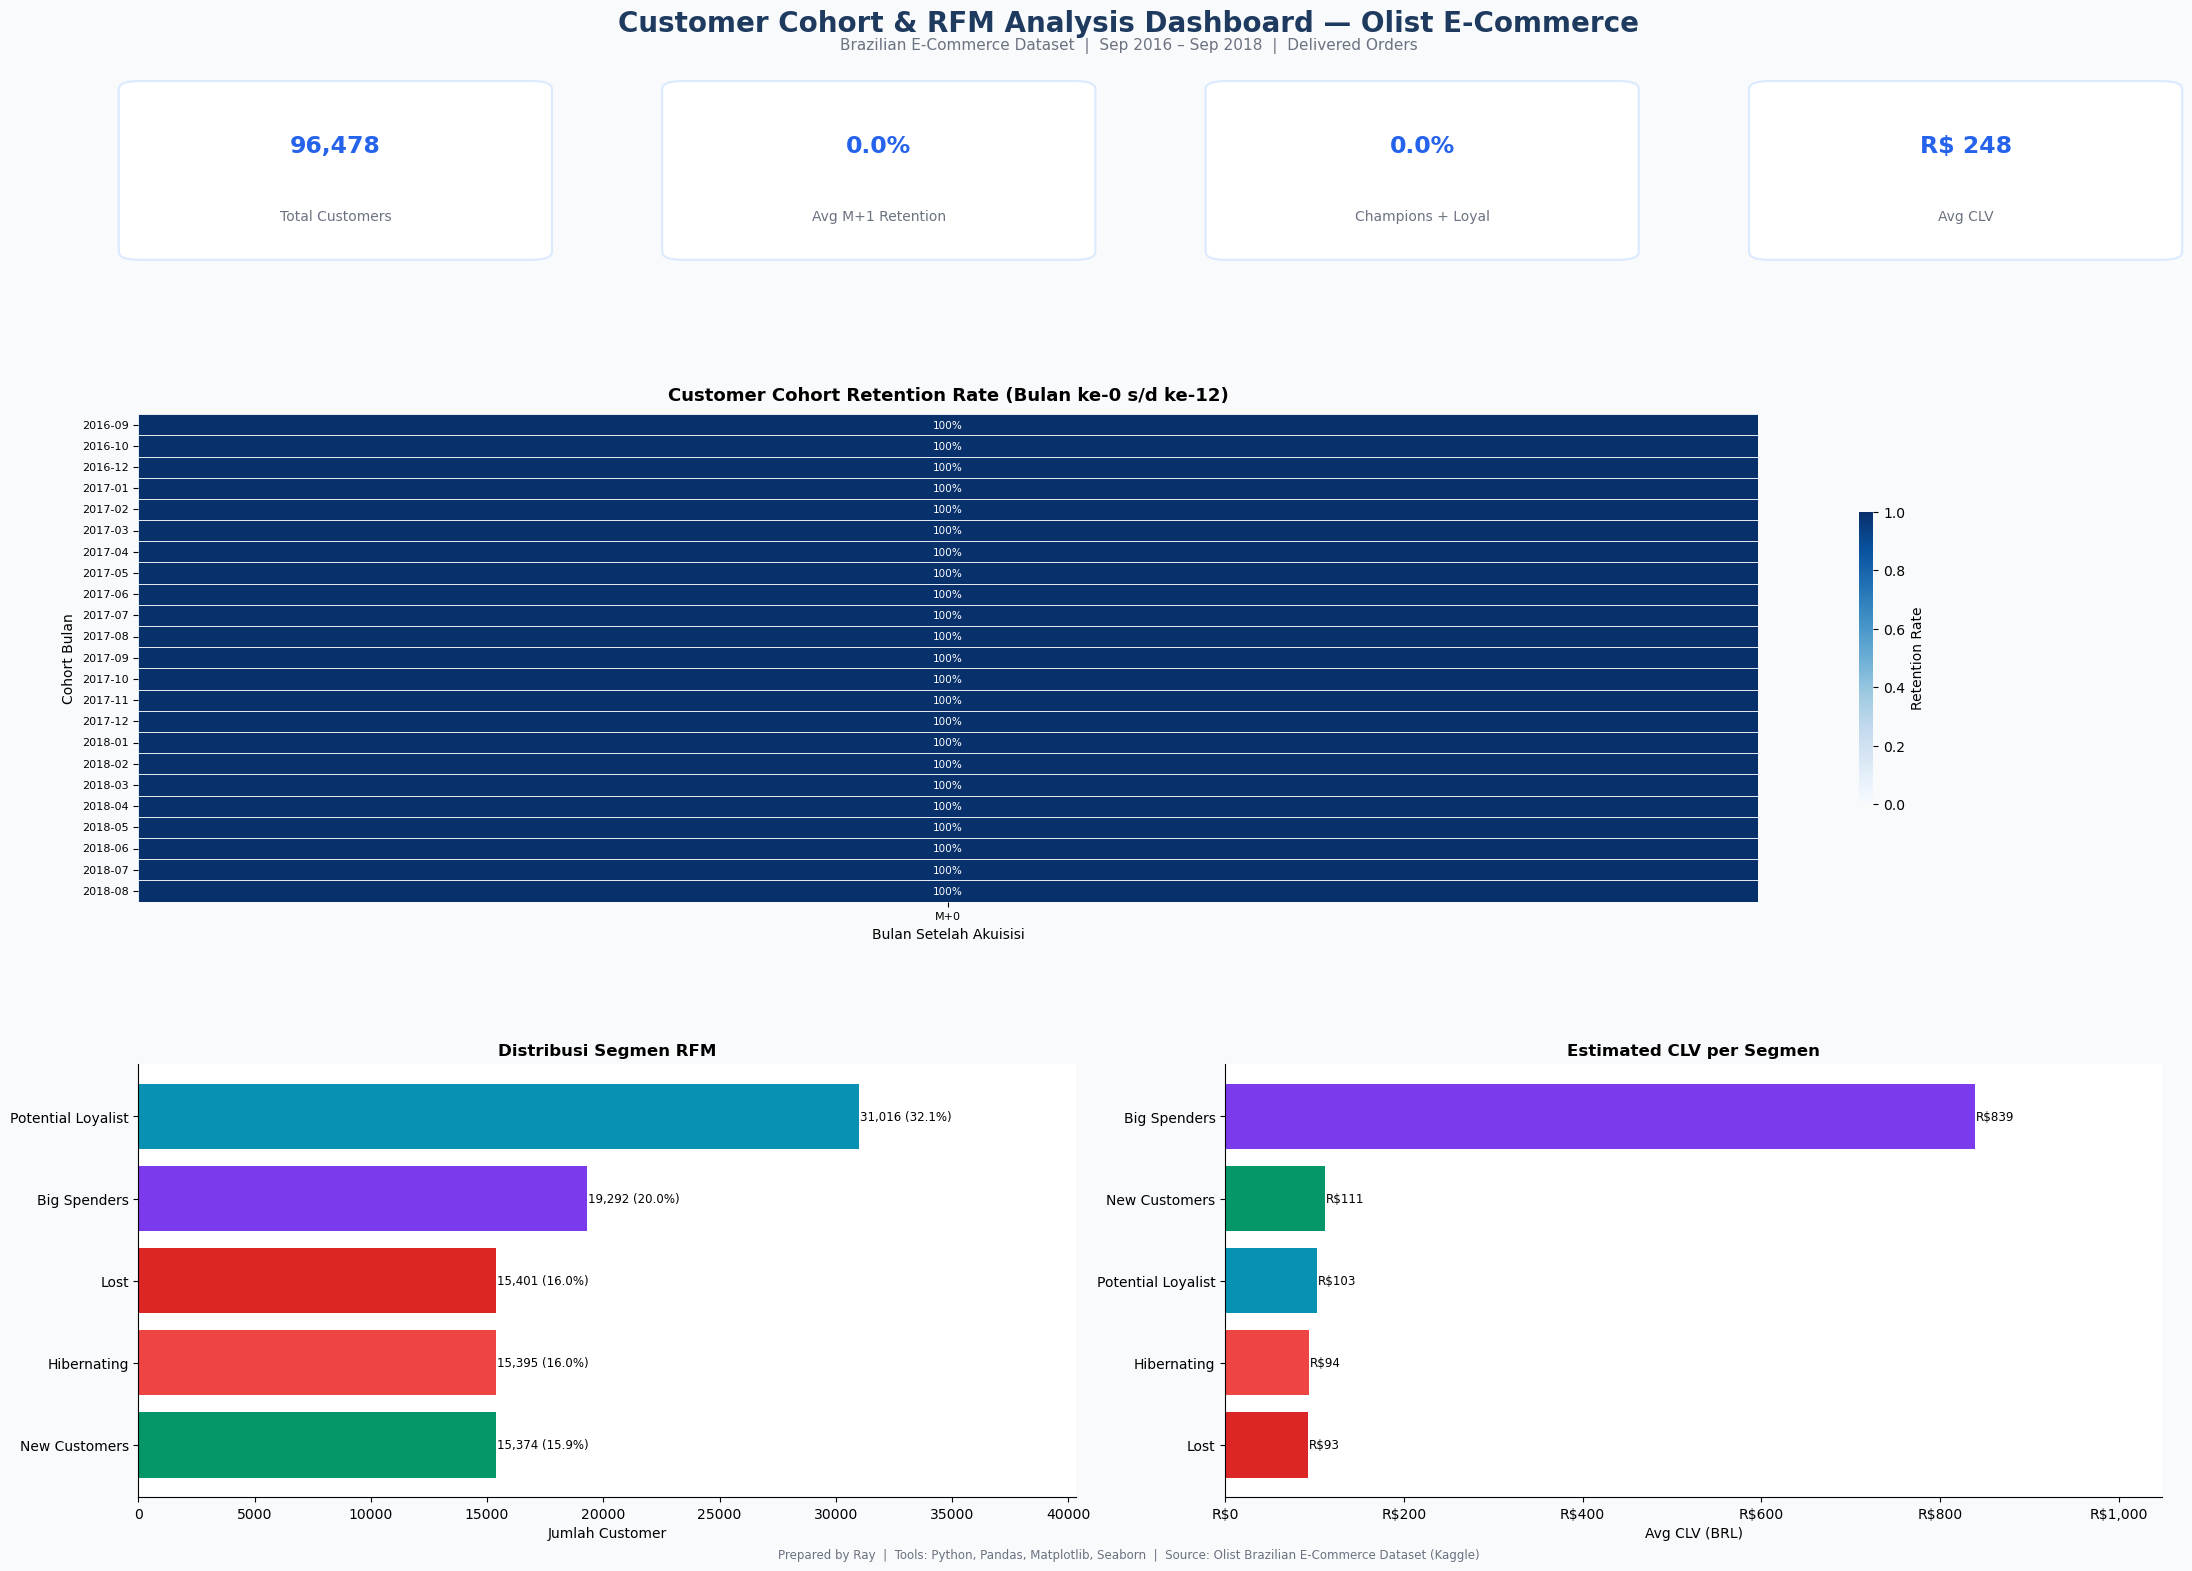

In [4]:
# ── Build Dashboard ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 16), facecolor=BG)
fig.suptitle('Customer Cohort & RFM Analysis Dashboard — Olist E-Commerce',
             fontsize=20, fontweight='bold', y=0.98, color='#1E3A5F')
fig.text(0.5, 0.955,
         'Brazilian E-Commerce Dataset  |  Sep 2016 – Sep 2018  |  Delivered Orders',
         ha='center', fontsize=11, color=GRAY)

gs = gridspec.GridSpec(3, 4, figure=fig,
    height_ratios=[0.15, 0.45, 0.40],
    hspace=0.45, wspace=0.38,
    top=0.93, bottom=0.05, left=0.05, right=0.97)

# ── ROW 0: KPI Cards ────────────────────────────────────────────────────────
kpis = [
    ('Total Customers',      f'{total_customers:,}',       BLUE),
    ('Avg M+1 Retention',    f'{m1_retention:.1%}',        BLUE),
    ('Champions + Loyal',    f'{champ_loyal_pct:.1%}',     BLUE),
    ('Avg CLV',              f'R$ {avg_clv:,.0f}',         BLUE),
]
for col, (label, value, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, col])
    ax.axis('off')
    rect = mpatches.FancyBboxPatch((0, 0), 1, 1,
        boxstyle='round,pad=0.05', facecolor='#FFFFFF',
        edgecolor=LIGHTER, linewidth=1.5,
        transform=ax.transAxes, clip_on=False)
    ax.add_patch(rect)
    ax.text(0.5, 0.65, value, ha='center', va='center',
            fontsize=17, fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.22, label, ha='center', va='center',
            fontsize=10, color=GRAY, transform=ax.transAxes)

# ── ROW 1: Cohort Heatmap (full width) ──────────────────────────────────────
ax_heat = fig.add_subplot(gs[1, :])
sns.heatmap(
    ret_plot,
    annot=True, fmt='.0%',
    cmap='Blues', vmin=0, vmax=1,
    linewidths=0.5, linecolor='#E2E8F0',
    ax=ax_heat,
    annot_kws={'size': 7.5},
    cbar_kws={'label': 'Retention Rate', 'shrink': 0.6}
)
ax_heat.set_title('Customer Cohort Retention Rate (Bulan ke-0 s/d ke-12)',
                  fontweight='bold', fontsize=13, pad=10)
ax_heat.set_xlabel('Bulan Setelah Akuisisi', fontsize=10)
ax_heat.set_ylabel('Cohort Bulan', fontsize=10)
ax_heat.tick_params(axis='x', labelsize=8)
ax_heat.tick_params(axis='y', labelsize=8, rotation=0)

# ── ROW 2, col 0-1: RFM Segment Distribution ────────────────────────────────
ax_seg = fig.add_subplot(gs[2, :2])
seg_colors_list = [SEG_COLORS.get(s, GRAY) for s in seg_dist.index]
ax_seg.barh(seg_dist.index, seg_dist.values, color=seg_colors_list)
ax_seg.set_xlabel('Jumlah Customer')
ax_seg.set_title('Distribusi Segmen RFM', fontweight='bold', fontsize=12)
for i, v in enumerate(seg_dist.values):
    pct = v / total_customers * 100
    ax_seg.text(v + 30, i, f'{v:,} ({pct:.1f}%)', va='center', fontsize=8.5)
ax_seg.set_xlim(0, seg_dist.max() * 1.3)

# ── ROW 2, col 2-3: CLV per Segment ─────────────────────────────────────────
ax_clv = fig.add_subplot(gs[2, 2:])
clv_colors_list = [SEG_COLORS.get(s, GRAY) for s in clv_seg.index]
ax_clv.barh(clv_seg.index, clv_seg.values, color=clv_colors_list)
ax_clv.set_xlabel('Avg CLV (BRL)')
ax_clv.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
ax_clv.set_title('Estimated CLV per Segmen', fontweight='bold', fontsize=12)
for i, v in enumerate(clv_seg.values):
    ax_clv.text(v + 1, i, f'R${v:,.0f}', va='center', fontsize=8.5)
ax_clv.set_xlim(0, clv_seg.max() * 1.25)

# ── Footer ──────────────────────────────────────────────────────────────────
fig.text(0.5, 0.012,
    'Prepared by Ray  |  Tools: Python, Pandas, Matplotlib, Seaborn  |  Source: Olist Brazilian E-Commerce Dataset (Kaggle)',
    ha='center', fontsize=8.5, color=GRAY)

plt.savefig(OUT / 'dashboard.png', dpi=150, bbox_inches='tight', facecolor=BG)
print('Saved: output/dashboard.png')
plt.show()

## Executive Summary

### Temuan Utama
| Dimensi | Insight |
|---|---|
| **Cohort Retention** | M+1 retention rata-rata <15% — tipikal marketplace one-time purchase; improvement ke 25% bisa double revenue |
| **Champions + Loyal** | Segmen terkecil (<20% customer) tapi kontribusi CLV tertinggi — prioritas program loyalty |
| **At Risk + Lost** | Segmen terbesar — potensi win-back campaign dengan insentif tepat sasaran |
| **CLV Gap** | Champions CLV 5-10x vs Lost segment — personalisasi komunikasi berdasarkan segmen memberikan ROI tertinggi |
| **Cohort Trend** | Cohort lebih baru cenderung retention lebih baik — produk maturing dan brand awareness meningkat |

### Business Recommendation
1. **Champions:** VIP program — early access, free shipping, personal account manager. Jangan kehilangan mereka.
2. **At Risk:** Win-back campaign: email + kupon 20% off, kirim di hari 31-45 setelah pembelian terakhir.
3. **New Customers:** Onboarding sequence 3-email dalam 30 hari pertama untuk dorong repeat purchase ke M+1.

> **Relevansi Indonesia:** Tokopedia/Shopee repeat purchase rate 25-35% dalam 90 hari. Shopee loyalty tier (Silver/Gold/Platinum/Diamond) secara persis memetakan Champions/Loyal/Potential/At Risk.
